# COMP1008 2025/26 Coursework - World Cup Performance Analysis

#### **Student Name**: [Gabrielle Hunt]
#### **Student ID**: [20728328]

## Task description

In this coursework, you will analyze historical World Cup team data and build basic machine learning models.
You should demonstrate clean data handling, clear feature engineering, and simple model evaluation.

**Dataset:** `WorldCup_Stats.csv`

**Main Task**: Utilizing the provided World Cup dataset, build a Linear Regression Model and another Machine Learning Model of your choice to predict `WorldCup_Classification`. Employ appropriate methods from the `pandas`, `matplotlib`, and `sklearn` libraries to analyze and process the dataset for building predictive models.<br>**Note**: You must use `only pandas, numpy, matplotlib, and sklearn`. Do not use other libraries or external packages. Use of such packages may receive zero credit for the affected parts.

**Format**: Use this Jupyter Notebook as a template to write your report in `Markdown` cells, supported by your source code in Code cells. Ensure your code produces the corresponding plots or results addressing the questions. Rename this `.ipynb` file to `202526_COMP1008_cw_XXX.ipynb`, where XXX is your username (e.g., psxyz), and submit it to Moodle by <b><font color = "red">24 March, 3pm</font></b>.

**Marks**: The coursework is worth a total of 100 marks (accounting for 25% of the COMP1008 module grade). Marks will be awarded based on your understanding of machine learning theories, the informativeness and presentation of your code, visualizations, results (e.g., code comments, necessary labels in plots), self-learning ability in solving the specific problem, and how succinct, concise, and clear your report writing is.

Please check the detailed instructions at the end of this template file.

### Key columns used in this coursework
- `Team`: Which worldcup team. 
- `Year`: Year of the event/worldcup. 
- `WorldCup_Classification`: Classification in the worldcup of the corresponding year (ranking of the positions). 
- `Pre_Tournament_World_Ranking`: Pre-event ranking.
- `Games_Played_Last_4_Years`, `Wins_Last_4_Years`, `Draws_Last_4_Years`, `Losses_Last_4_Years`: Pre-worldcup Four-year match-volume and results history.
- `Goals_For_Last_4_Years`, `Goals_Against_Last_4_Years`, `Goal_Difference_Last_4_Years`: Pre-worldcup Four-year attacking, defensive, and net-goal history.
- `Group_Goals_For`, `Group_Goals_Against`, `Avg_Group_Goals_For`, `Avg_Group_Goals_Against`, `Avg_Group_Goal_Difference`: Group-stage outcomes for the worldcup of the corresponding year.
- `Playoff_Goals_For`, `Playoff_Goals_Against`, `Playoff_Matches_Played`, `Avg_Playoff_Goals_For`, `Avg_Playoff_Goals_Against`, `Avg_Playoff_Goal_Difference`: Playoff history for the worldcup of the corresponding year.
- `Team_Continent`: Categorical context features highlighting the team continent.
- `Host_Continent`: Host continent for the specific worldcup.
- Engineered required features in Q1d: `Points_Per_Game_Last_4_Years`, `Goal_Pro_Last_4_Years`, `Goal_Con_Last_4_Years`, `Goal_Diff_Last_4_Years`.


In [1]:
# You can change the import statements as you wish, but you should not use any library beyond pandas, numpy, matplotlib, and sklearn.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


<div class="alert alert-success" style="text-align:left;">
<h2>Question 1. Data Analysis and Preparation<span style="float:right;">[35 marks]</span></h2></div>


#### Question 1a <span style="color:red">(5 marks)</span>

Briefly explain why this World Cup dataset is suitable for a regression task with target `WorldCup_Classification`.  <br>
Support your judgment with a brief evidence check from the data. 
- Provide your answer in bullet points.
- Include at least **2 concise reasons**.

Your justification should demonstrate your understanding of the linear regression model.

<b>Q1a Answer</b>: - A linear regression model maps a relationship of an output based on inputs. In this case, the target is World Cup Classification which works because it is a numerical and ordered value which can be predicted based on inputs.
- Other values from the table can be used as inputs to predict world cup classifications making this useful for a linear regression model task.
- I have shown below that the values are numerical by outputting the column with the values, you can see they range from 1 to 32.


In [2]:
data = pd.read_csv("WorldCup_Stats.csv")
print(data["WorldCup_Classification"])

0       1
1       2
2       3
3       4
4       5
       ..
611    28
612    29
613    30
614    31
615    32
Name: WorldCup_Classification, Length: 616, dtype: int64


---


#### Question 1b <span style="color:red">(5 marks)</span>

Evaluate the dataset quality before modelling.
Use appropriate methods from `numpy`, `pandas` and/or `matplotlib` to inspect potential data issues, specify which part(s) of the dataset affected, and explain what could happen if preprocessing is not done properly.

- Provide at least **2 short code-based checks**, demonstrating how you analyze these issues.
- Briefly explain how each code snippet supports your evaluation of potential issues.


<b>Q1b Answer</b>: I first decided to check whether there were null values within the data. This was easily completed and I found there were null values in columns for pre tournament ranking and goal difference. I will have to decide what to do with these to prevent my model being skewed by this missing data. I will either remove these rows or fill them with a value such as a mean. Missing rankings will cause the model to fail or make bias estimations.

I then created several scatter plots to see if I could identify any outliers in the data. While there were some pieces of data that seemed out of place, this is purely the result of stronger team performance, not incorrect data and so I feel it is okay to keep these within the dataset. I did this for several of the numerical categories such as goal difference and wins.

Year                              0
Team                              0
Team_Continent                    0
Host_Continent                    0
Pre_Tournament_World_Ranking    319
Games_Played_Last_4_Years         0
Wins_Last_4_Years                 0
Draws_Last_4_Years                0
Losses_Last_4_Years               0
Goals_For_Last_4_Years            0
Goals_Against_Last_4_Years        0
Group_Goals_For                   0
Group_Goals_Against               0
Avg_Group_Goals_For               0
Avg_Group_Goals_Against           0
Avg_Group_Goal_Difference         0
Playoff_Goals_For                 0
Playoff_Goals_Against             0
Playoff_Matches_Played            0
Avg_Playoff_Goals_For             0
Avg_Playoff_Goals_Against         0
Avg_Playoff_Goal_Difference       0
WorldCup_Classification           0
Goal_Difference_Last_4_Years     22
dtype: int64


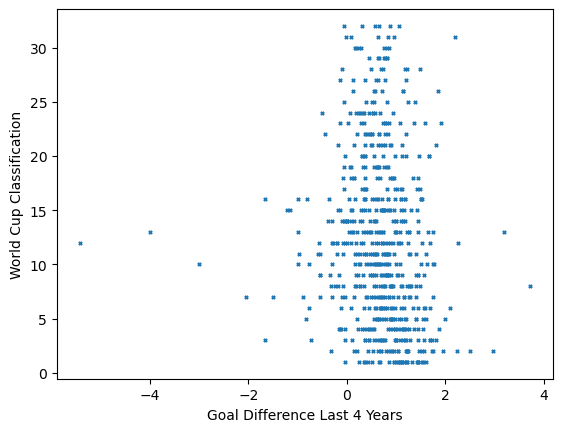

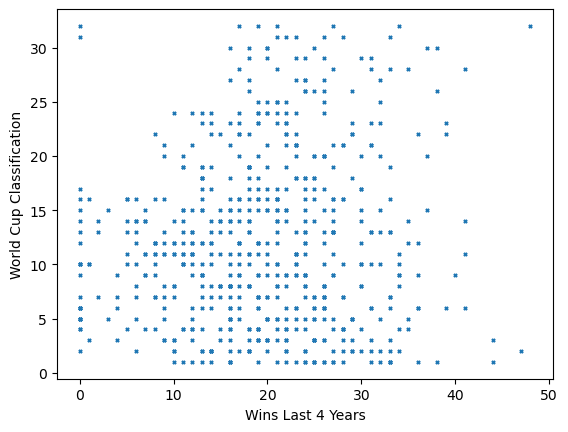

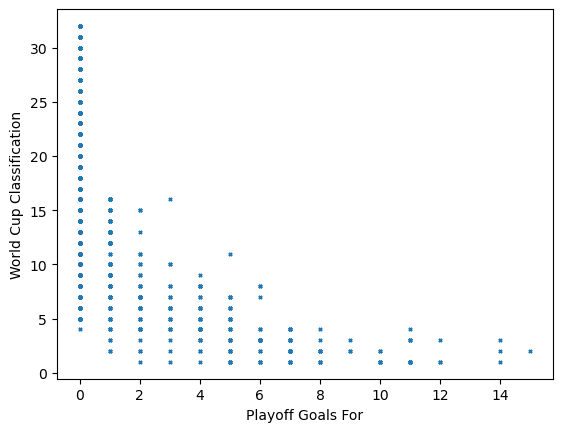

In [3]:
data = pd.read_csv("WorldCup_Stats.csv")
print(data.isnull().sum())

plt.scatter(data['Goal_Difference_Last_4_Years'],data['WorldCup_Classification'],s=5,marker='x')
plt.xlabel('Goal Difference Last 4 Years')
plt.ylabel('World Cup Classification')
plt.show()

plt.scatter(data['Wins_Last_4_Years'],data['WorldCup_Classification'],s=5,marker='x')
plt.xlabel('Wins Last 4 Years')
plt.ylabel('World Cup Classification')
plt.show()

plt.scatter(data['Playoff_Goals_For'],data['WorldCup_Classification'],s=5,marker='x')
plt.xlabel('Playoff Goals For')
plt.ylabel('World Cup Classification')
plt.show()


---


#### Question 1c <span style="color:red">(10 marks)</span>

Based on your findings from **Question 1b**, refine and clean the dataset for modelling.
Review the table for preprocessing issues that could distort model training, including, among others other reasons, incomplete information and outliers (for example, teams with too few games, no games, or unusually many games).

For this stage, **avoid using direct team identity** and **event year** as analysis inputs when preparing converted model features.

Provide code that addresses the issues you identified and briefly explain the methods and parameters you used.


<b>Q1c Answer</b>: To replace the missing data, I had two columns to deal with, for the pre-tournament missing data, I just gave the teams with no data the upper quartile value, which I obtained from using 'describe' as I feel this places them at a fair place which won't affect the data in too biased of a way. 
For the goal difference for the last 4 years, I just gave them the median as I feel this would be a fairly accurate value for teams who haven't played in the past years as all values are quite close together in this column.
For the outliers I identified previously I have left them, since they hold real values and meaning e.g. stronger team performances and therefore are important to the classification of world cup winner. Apart from the games played in the last 4 years, which I have removed when they have 0 as this gives no extra information to this task.

In [4]:
data = pd.read_csv("WorldCup_Stats.csv")

print(data['Pre_Tournament_World_Ranking'].describe())
upper_quartile = 28
data['Pre_Tournament_World_Ranking'] = data['Pre_Tournament_World_Ranking'].fillna(upper_quartile)
print(data['Pre_Tournament_World_Ranking'])

med = data['Goal_Difference_Last_4_Years'].median()
data['Goal_Difference_Last_4_Years'] = data['Goal_Difference_Last_4_Years'].fillna(med)
print(data['Goal_Difference_Last_4_Years'])

count    297.000000
mean      19.060606
std       17.095608
min        1.000000
25%        5.000000
50%       15.000000
75%       28.000000
max      105.000000
Name: Pre_Tournament_World_Ranking, dtype: float64
0      28.0
1      28.0
2      28.0
3      28.0
4      28.0
       ... 
611    10.0
612    21.0
613    19.0
614    41.0
615    50.0
Name: Pre_Tournament_World_Ranking, Length: 616, dtype: float64
0      1.074074
1      1.960000
2     -1.666667
3     -0.111111
4      0.875000
         ...   
611    1.477273
612    0.625000
613    0.166667
614    2.200000
615    0.655738
Name: Goal_Difference_Last_4_Years, Length: 616, dtype: float64


---


#### Question 1d <span style="color:red">(15 marks)</span>

**TASK 1:** Data engineering: An important aspect of machine learning is understanding the feature space and shaping it before training. That is, preprocessing or reshaping the data in a way that provides more relevant information and an easier job for the regressor or classifier. 

In this context:  Create the following per-game features by writing the equations in code. These represents the average of points per game, and the average goals (pro: in favor;  con: opposite goals;   diff: difference) for the past 4 years before the world cup.  These four features should be included in your data input for analysis. 

- `Points_Per_Game_Last_4_Years = (3 * Wins_Last_4_Years + Draws_Last_4_Years) / Games_Played_Last_4_Years`
- `Goal_Pro_Last_4_Years = (Goals_For_Last_4_Years) / Games_Played_Last_4_Years`
- `Goal_Con_Last_4_Years = (Goals_Against_Last_4_Years) / Games_Played_Last_4_Years`
- `Goal_Diff_Last_4_Years = (Goals_For_Last_4_Years - Goals_Against_Last_4_Years) / Games_Played_Last_4_Years`
<br>  

**Important**: As highlighted in item 1.C, you should not use the `team` identity and event `year` in your data. 

<br>
**TASK 2:** Assess whether all data is ready for regression. If not, complete the preparation of a model-ready table from your cleaned dataset. More specifically, make sure to assess whether all predictors in your prepared table are directly suitable for linear regression.
State what (if anything) still needs processing, and process / make the necessary adjustment in the data accordingly.   


<b>Q1d Answer</b>: All data is now ready for regression as anything that isn't numerical has been removed e.g. team and host continent. All null values have been filled previously with appropriate data and I have made sure there are none left in the code below. There are also now new columns created which give us new helpful information. These can give more insight such as a higher points per game can give a team a better ranking. The fact that these establish points per game as well allows us to get less biased data since teams playing less games will not be disadvantaged.


In [5]:

data['Points_Per_Game_Last_4_Years'] = (3 * data['Wins_Last_4_Years'] + data['Draws_Last_4_Years']) / data['Games_Played_Last_4_Years']
data['Goal_Pro_Last_4_Years'] = data['Goals_For_Last_4_Years'] / data['Games_Played_Last_4_Years']
data['Goal_Con_Last_4_Years'] = data['Goals_Against_Last_4_Years'] / data['Games_Played_Last_4_Years']
data['Goal_Diff_Last_4_Years'] = (data['Goals_For_Last_4_Years'] - data['Goals_Against_Last_4_Years']) / data['Games_Played_Last_4_Years']
print(data['Points_Per_Game_Last_4_Years'])

data = data.drop(columns=['Year', 'Team', 'Team_Continent', 'Host_Continent'])
data = data.fillna(0)
print(data.isnull().sum())

0      1.777778
1      1.960000
2      1.333333
3      1.388889
4      1.375000
         ...   
611    2.045455
612    1.850000
613    1.690476
614    2.200000
615    1.836066
Name: Points_Per_Game_Last_4_Years, Length: 616, dtype: float64
Pre_Tournament_World_Ranking    0
Games_Played_Last_4_Years       0
Wins_Last_4_Years               0
Draws_Last_4_Years              0
Losses_Last_4_Years             0
Goals_For_Last_4_Years          0
Goals_Against_Last_4_Years      0
Group_Goals_For                 0
Group_Goals_Against             0
Avg_Group_Goals_For             0
Avg_Group_Goals_Against         0
Avg_Group_Goal_Difference       0
Playoff_Goals_For               0
Playoff_Goals_Against           0
Playoff_Matches_Played          0
Avg_Playoff_Goals_For           0
Avg_Playoff_Goals_Against       0
Avg_Playoff_Goal_Difference     0
WorldCup_Classification         0
Goal_Difference_Last_4_Years    0
Points_Per_Game_Last_4_Years    0
Goal_Pro_Last_4_Years           0
Goal_Con_Las

---


<div class="alert alert-success" style="text-align:left;">
<h2>Question 2. Regression Model<span style="float:right;">[35 marks]</span></h2></div>


#### Question 2a <span style="color:red">(10 marks)</span>

**TASK:** You have now being assigned to predict the world-club calssification **based on the results from the four years before the world-cup (remember that world-cups take place every 4 year) and the group stage results**. You are suppose to use all the data from the dataset `except the ones that related to the playoffs. Remove those from your analysis`.  
<b>Hint</b>: The name of the `team` and the `year` of the event should not influence your prediction, and **should also be excluded from analysis**. <br> In other words, exclude all playoff-related columns from your model inputs. Also exclude Team and Year from the model features.<br>

Now, build a baseline linear regression pipeline to predict `WorldCup_Classification` using the preprocessed dataset. 

- Train the model and report **three different** evaluation metrics.
- For each metric, explain (in a single short sentence) why it is relevant and whether the observed value suggests sensible ranking predictions, i.e. what the values within the metric mean. 


<b>Q2a Answer</b>: First off, I dropped all playoff columns, team and year did not need to be dropped again as I had previously already dropped them. I then imported train_test_split so that I could split the data into a training set and a test set and use this on a linear regression model.

Mean Square Error: The first evaluation metric I tried out was MSE which calculates the average of the squared differences between the predicted and actual values because they are squared, larger errors are made bigger and so outliers are more noticeable. The outcome suggests sensible rank predictions as if you square root it, it comes out at about 5, so each team could be about 5 positions off.

Root Mean Square Error: This is the same as Mean Square Error however it brings it back to the original target scale like I had to do manually when using Mean Square Error. This allows us to clearly see how far away our teams could be from their actual classification. As you can see it does come out about 5 positions off. I just wanted to add this to check that my MSE calculation was correct.

R2 Score: This means around half the variation in my ranking can be explained by the features. 

Mean Absolute Error: This gives a value of 4.426... which means that our teams classifications could be off by a factor of 4, this test is less considerate of outliers as it doesn't scale anything, it just takes the values as they are. I am pleased with this as considering there can be up to 32 teams a MAE of 4 is quite accurate.


In [6]:
print(data.columns)
data = data.drop(columns=['Playoff_Goals_For', 'Playoff_Goals_Against', 'Playoff_Matches_Played',
       'Avg_Playoff_Goals_For', 'Avg_Playoff_Goals_Against',
       'Avg_Playoff_Goal_Difference'])
x = data.drop(columns=['WorldCup_Classification'])
y = data['WorldCup_Classification']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

from sklearn import metrics
y_pred = lr.predict(x_test)
print('\n Mean Square Error (MSE): ',metrics.mean_squared_error(y_test, y_pred))
print('\n Root Mean Square Error (RMSE): ',metrics.root_mean_squared_error(y_test, y_pred))
print('\n Mean Absolute Error (MAE): ',mean_absolute_error(y_test, y_pred))
print('\n R2 Score (r2): ', r2_score(y_test, y_pred))

Index(['Pre_Tournament_World_Ranking', 'Games_Played_Last_4_Years',
       'Wins_Last_4_Years', 'Draws_Last_4_Years', 'Losses_Last_4_Years',
       'Goals_For_Last_4_Years', 'Goals_Against_Last_4_Years',
       'Group_Goals_For', 'Group_Goals_Against', 'Avg_Group_Goals_For',
       'Avg_Group_Goals_Against', 'Avg_Group_Goal_Difference',
       'Playoff_Goals_For', 'Playoff_Goals_Against', 'Playoff_Matches_Played',
       'Avg_Playoff_Goals_For', 'Avg_Playoff_Goals_Against',
       'Avg_Playoff_Goal_Difference', 'WorldCup_Classification',
       'Goal_Difference_Last_4_Years', 'Points_Per_Game_Last_4_Years',
       'Goal_Pro_Last_4_Years', 'Goal_Con_Last_4_Years',
       'Goal_Diff_Last_4_Years'],
      dtype='object')

 Mean Square Error (MSE):  31.42792475541845

 Root Mean Square Error (RMSE):  5.606061429864861

 Mean Absolute Error (MAE):  4.426369007080915

 R2 Score (r2):  0.46149065248983356


#### Question 2b <span style="color:red">(10 marks)</span>

- Interpret the fitted regression model through its coefficients. 
- Identify the strongest effects
- Comment on the signs/magnitudes of the ones with strongest effects, and briefly discuss their meaning for the worldcup classification and why they are plausible or not.


<b>Q2b Answer</b>: The 5 strongest effects are Goal_Diff_Last_4_Years, Goal_Difference_Last_4_Years, Goal_Pro_Last_4_Years, Points_Per_Game_Last_4_Years, Goal_Con_Last_4_Years

Goal Difference Last 4 Years: Positive, so that means teams will have a higher (worse) ranking. This is not plausible as the team with a better goal difference means they've scored more than they've let in which should mean a better ranking, however this is a large coefficient so small changes will affect ranking a lot. This could be wrong because multiple features correlate with the goal difference feature. 

Points Per Game Last 4 Years: Positive, so that means that teams will have a higher (worse) ranking. This is not correct as teams should have a better ranking if they have scored more points per game. This may be incorrect as it has overlap with other features.

Goals pro last 4 Years: Negative, so that means teams will have a lower (better) ranking. This makes sense as more goals scored for your team shows a strong team performance.

Goal Diff Last 4 Years: Negative, so teams will have a lower (better) ranking. This makes sense as a better goal difference means you have scored more goals than you've conceded, showing a strong team performance. What about this

Goal Con Last 4 Years: Positive, this means teams will have a higher (worse) ranking. This makes sense since teams who have conceded more goals will have weaker team performance.


In [7]:
coef_table = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficients": lr.coef_
})
print(coef_table)

                         Feature  Coefficients
0   Pre_Tournament_World_Ranking      0.085049
1      Games_Played_Last_4_Years      0.154754
2              Wins_Last_4_Years     -0.026495
3             Draws_Last_4_Years     -0.003046
4            Losses_Last_4_Years      0.184295
5         Goals_For_Last_4_Years      0.002201
6     Goals_Against_Last_4_Years     -0.072708
7                Group_Goals_For     -1.019424
8            Group_Goals_Against      0.451525
9            Avg_Group_Goals_For      0.043640
10       Avg_Group_Goals_Against      0.671629
11     Avg_Group_Goal_Difference     -0.627989
12  Goal_Difference_Last_4_Years      7.987110
13  Points_Per_Game_Last_4_Years      1.800097
14         Goal_Pro_Last_4_Years     -3.252244
15         Goal_Con_Last_4_Years      2.502027
16        Goal_Diff_Last_4_Years     -5.754272


---


#### Question 2c <span style="color:red">(15 marks)</span>

Now, you should train another with another regressor of your choice, and compare both results. 
- train **one additional regressor model** of your choice;

**Task 1:** Plot prediction quality alongside with the scatter plots for the real data. 

For each model (baseline linear regressor and your second regressor):
- plot `Actual rank` vs `Predicted rank` as a scatter plot.
- add a fitted linear trend line on top of the scatter points.
<br>

**Task 2:** 
- Then compare model performance with appropriate regression metrics and briefly state which model is more reliable for this task, and why? You can analyse the plot, or use the evaluation metrics from 2a).


<b>Q2d Answer</b>: 
I decided that the Random Forest Regressor is more reliable for this task, as it has a lower MSE by quite a large amount and this means the predicted values are closer to the actual values. The Random Forest MSE is 20.2 as opposed to the Linear Regression MSE which is 31.4. This is a significant difference. It also has a higher R2, which also indicates better accuracy. This is probably because the Random Forest Regressor is better at handling outliers. You can also see from the graph that the Random Forest Regressor plot is closer to the ideal diagonal line which we would want. From the graphs themselves, I can see that the Random Forest Regressor points plotted cluster closer to the line. 

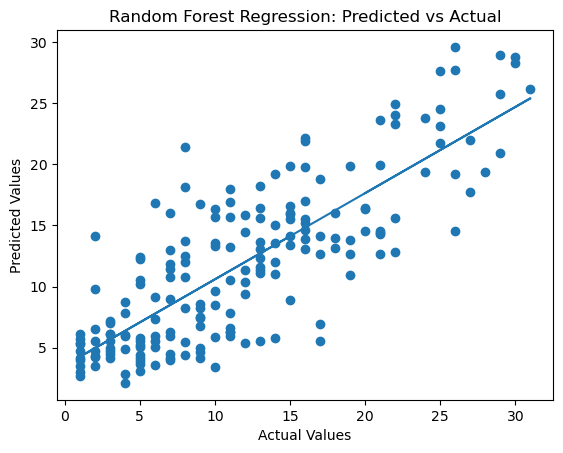

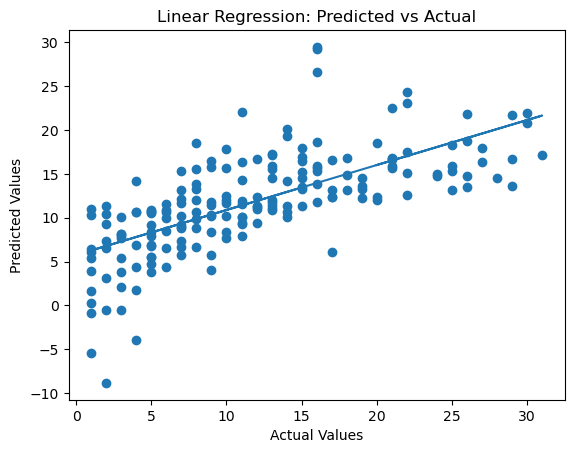

Linear Regression
MSE: 31.42792475541845
R2: 0.46149065248983356

Random Forest Regression
MSE: 20.21272864864865
R2: 0.6536601318511428


In [8]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x_train, y_train)
y_pred_rfr = rfr.predict(x_test)

a, b = np.polyfit(y_test, y_pred_rfr, 1)
plt.plot(y_test, a*y_test + b)

plt.scatter(y_test, y_pred_rfr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: Predicted vs Actual")
plt.show()

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

a, b = np.polyfit(y_test, y_pred_lr, 1)
plt.plot(y_test, a*y_test + b)

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest Regression")
print("MSE:", mean_squared_error(y_test, y_pred_rfr))
print("R2:", r2_score(y_test, y_pred_rfr))


<div class="alert alert-success" style="text-align:left;">
<h2>Question 3. Classification and Reflection<span style="float:right;">[30 marks]</span></h2></div>


#### Question 3a <span style="color:red">(15 marks)</span>

Build a classifier to predict whether a team reaches the quarter-finals (`WorldCup_Classification <= 8`).

Use cleaned/model-ready features and evaluate the classifier clearly.

- Define the binary target (`Reached_QuarterFinals`): 1 if the team reached the quarters and 0, otherwise.
- Train one classifier.
- Report model quality with clear evidence (Use: accuracy, precision, recall, F1, confusion matrix).
- Briefly comment on strengths and limitations of your model.


<b>Q3a Answer</b>: This model is of good quality and I can tell from the evidence I have produced.
The accuracy is placed at around 84%, which means that it has classified this percent of the data correctly. This is a good majority and so I can say that the model is accurate.
The precision is also quite high as it shows that when the model predicts who has reached the quarter finals, it is around 83% accurate.
The recall checks out of how many teams that actually reached the quarter finals, how many of them were predicted correctly, this is again quite high with about 73%.
The f1 is also high with a balance of precision and recall around 78%.
The Confusion Matrix is especially important and indicative of the high quality of my model, as it shows that 69 teams predicted to not reach quarter finals were predicted correctly, and 7 weren't predicted correctly and for the opposite, 13 teams were predicted incorrectly and 35 teams predicted correctly.

The strengths of the model are that it has strong accuracy and precision. However, the limitations are that the recall is slightly lower and so some teams that did make it to the quarter final were not picked up on by the model. 

In [9]:
data['Reached_QuarterFinals']=(data['WorldCup_Classification'] <= 8).astype(int)
X = data.drop(['WorldCup_Classification','Reached_QuarterFinals'], axis=1)
y = data['Reached_QuarterFinals']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

t_model = RandomForestClassifier(random_state=42)
t_model.fit(x_train,y_train)
y_predict = t_model.predict(x_test)
print('Testing accuracy: ', accuracy_score(y_test, y_predict))
print('Testing precision: ', precision_score(y_test, y_predict))
print('Testing recall: ', recall_score(y_test, y_predict))
print('Testing f1: ', f1_score(y_test, y_predict))
print('Confusion Matrix: ', confusion_matrix(y_test, y_predict,))

Testing accuracy:  0.8387096774193549
Testing precision:  0.8333333333333334
Testing recall:  0.7291666666666666
Testing f1:  0.7777777777777778
Confusion Matrix:  [[69  7]
 [13 35]]


---


#### Question 3b <span style="color:red">(15 marks)</span>

For your classifier in 3a, complete the following tasks:

- Train a different classifier to predict teams that reach the quarters-finals (`Reached_QuarterFinals <= 8`), and compare the models/results with the one from 3a.using a classification metric.
- Identify the most influential input variables.
- Remove the 3 least relevant variables (from your 3a importance analysis), retrain, and report how the output changes.


<b>Q3b Answer</b>: I trained a logistic regression model as an alternative to the random forest classifier. It has a lower accuracy and precision than the random forest classifier, while the random forest classifier has a lower recall and f1. The confusion matrix are very similar but model 2 is slightly better as it predicts more teams reaching the quarter finals correctly. This is why the recall and f1 score are improved but not the accuracy and precision. This is probably because the logistic model assumes linear relationships and so does not consider outliers as much as the Random Forest Regressor.

The most influential input variables are Avg_Group_Goal_Difference, Avg_Group_Goals_For and Group_Goals_For.
The least relevant variables are Draws_Last_4_Years, Losses_Last_4_Years and Goals_Against_Last_4_Years.
I will now retrain my model from 3a.

As you can see the model now has better accuracy, precision, recall and f1 than both the models previously done. This is probably due to the fact that these low relevance variables can no longer affect the data, which is good as they will introduce less noise.

In [10]:
data['Reached_QuarterFinals']=(data['WorldCup_Classification'] <= 8).astype(int)
X = data.drop(['WorldCup_Classification','Reached_QuarterFinals'], axis=1)
y = data['Reached_QuarterFinals']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(x_train,y_train)
y_predict = log_model.predict(x_test)
print('Testing accuracy: ', accuracy_score(y_test, y_predict))
print('Testing precision: ', precision_score(y_test, y_predict))
print('Testing recall: ', recall_score(y_test, y_predict))
print('Testing f1: ', f1_score(y_test, y_predict))
print('Confusion Matrix: ', confusion_matrix(y_test, y_predict))

importances = t_model.feature_importances_
importance_data = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})

print(importance_data)

X = data.drop(['WorldCup_Classification','Reached_QuarterFinals','Draws_Last_4_Years', 'Losses_Last_4_Years', 'Goals_Against_Last_4_Years'], axis=1)
y = data['Reached_QuarterFinals']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

t_model = RandomForestClassifier(random_state=42)
t_model.fit(x_train,y_train)
y_predict = t_model.predict(x_test)
print('Testing accuracy: ', accuracy_score(y_test, y_predict))
print('Testing precision: ', precision_score(y_test, y_predict))
print('Testing recall: ', recall_score(y_test, y_predict))
print('Testing f1: ', f1_score(y_test, y_predict))
print('Confusion Matrix: ', confusion_matrix(y_test, y_predict,))

Testing accuracy:  0.8306451612903226
Testing precision:  0.8260869565217391
Testing recall:  0.7450980392156863
Testing f1:  0.7835051546391752
Confusion Matrix:  [[65  8]
 [13 38]]
                         Feature  Importance
0   Pre_Tournament_World_Ranking    0.039203
1      Games_Played_Last_4_Years    0.033206
2              Wins_Last_4_Years    0.033538
3             Draws_Last_4_Years    0.029877
4            Losses_Last_4_Years    0.031343
5         Goals_For_Last_4_Years    0.035160
6     Goals_Against_Last_4_Years    0.031858
7                Group_Goals_For    0.104212
8            Group_Goals_Against    0.065058
9            Avg_Group_Goals_For    0.111919
10       Avg_Group_Goals_Against    0.079819
11     Avg_Group_Goal_Difference    0.198829
12  Goal_Difference_Last_4_Years    0.044319
13  Points_Per_Game_Last_4_Years    0.041322
14         Goal_Pro_Last_4_Years    0.044426
15         Goal_Con_Last_4_Years    0.041092
16        Goal_Diff_Last_4_Years    0.034817
Testing

## Appendix. Coursework Instructions

<b>Coursework Support</b>:
- COMP1008 computing tutorials and exercises on data processing and machine learning models on different example problems
- Example code building and analysing machine learning models in COMP1008 lectures slides on 'Machine learning'
- In the computing sessions, Q&A support for developing .ipynb projects

<b>Marks</b>: in total 100 marks (count for 25% in COMP1008), awarded on the basis of:
- knowledge and understanding on the theories covered in lectures when answering the questions in the Jupyter Notebook report
- how informative and well presented your code, visualisations and results are (e.g. necessary labels in plots)
- self-learning ability making use of tutorial materials and online resources
- problem solving skills to obtain the answers and results for the specific dataset
- concise report with key details, e.g. parameters, data, etc. for others to repeat your methods and obtain the same results.

For more information of COMP1008 assessment please refer to the coursework issue in Moodle ('Course Content / Assessment').

<b>Format</b>:
- One single .ipynb file named `202526_COMP1008_cw_XXX.ipynb`, where XXX is your username (e.g. psxyz)
- The .ipynb file should include your code and answers, using this given .ipynb template (please add cells as needed)
- You **should not** use additional Python libraries. Only use the libraries already provided in this work. 
- There are multiple ways using different methods to complete the tasks. These are fine as long as all answers and analysis are supported by the code implemented in Jupyter Notebook, not by using other means (e.g. operations in Excel, or by using other languages, etc.).

<b>Submission</b>: 
- Deadline: <b><font color = "red">24 March, 3pm</font></b>.
- Late submission leads to a 5% deduction of the coursework on each weekday. Work submitted one week late will receive a 0 for the coursework.
- Method: in Moodle submit a single .ipynb file named `202526_COMP1008_cw_XXX.ipynb`
- If you can’t submit your coursework on time due to ECs, please contact Student Services and your personal tutor ASAP

----

## Academic Integrity

This is an individual coursework. You must complete all work independently.

**Plagiarism vs. Group Discussion Policy:**
- You may discuss general machine learning concepts and theories covered in COMP1008 lectures.
- You **must NOT**, under any circumstances, share code, figures, results, or specific implementation details with anyone else.
- You **must not** work in groups or discuss specific approaches to answering the coursework questions.
- It is important that when you actually do your coursework and write the answers, you do it individually.<br>
- Plagiarism is completely unacceptable and will be dealt with according to the University's standard policies.

**AI Tools Policy:**

The use of AI tools such as ChatGPT, GitHub Copilot, or any AI assistant is **not permitted** for this coursework.

This coursework is designed to develop your understanding of machine learning concepts and your ability to implement data analysis and modeling techniques. Using AI tools would undermine these learning outcomes and prevent you from developing essential skills for your career.  

**Examples of academic misconduct using AI include:**
- Using AI to write any part of the code, whether copied directly, rewritten, or used as a reference.
- Using AI to suggest improvements, debugging assistance, or to write comments.
- Using AI-based code completion functions in IDEs or text editors.
- Asking AI for guidance on how to solve any part of the coursework questions.

**Permitted tools:**
- Standard syntax highlighting and basic code completion (e.g., showing available functions within a class).
- Official Python, pandas, numpy, matplotlib, and sklearn documentation.

If you have questions about what constitutes appropriate use of resources, please contact the module leaders before proceeding.